# Modèle — résultat de match (1X2)

On prédit `result` ∈ {`home_win`, `draw`, `away_win`} à partir des 16 features d'équipe
(`data/training_match_dataset.csv`).

**Contraintes qui dictent la méthode :**
- **Petit dataset** (873 matchs) → modèles simples et régularisés, pas de gros réseau.
- **3 classes déséquilibrées** (le nul est minoritaire) → on regarde le **log-loss** et le **par-classe**, pas que
  l'accuracy.
- **Matchs ordonnés dans le temps** → split **chronologique** (train = passé, test = futur). Un split aléatoire
  ferait fuiter de l'information du futur et gonflerait les scores.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

RANDOM_STATE = 42
COLOR_HIGHLIGHT, INK, INK_SOFT = "#2a78d6", "#0b0b0b", "#52514e"
BLUES = LinearSegmentedColormap.from_list("blues", ["#f0efec", "#9ec5f4", "#3987e5", "#184f95"])
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c9c8c3",
    "axes.labelcolor": INK_SOFT, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "text.color": INK, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "grid.color": "#e6e5e0", "font.size": 10,
})

df = pd.read_csv("data/training_match_dataset.csv", parse_dates=["match_date"])
DROP_SUFFIXES = ("_attack", "_midfield", "_defence")   # redondants avec overall -> retirés
feature_cols = [c for c in df.columns
                if (c.startswith("home_") or c.startswith("away_"))
                and not c.endswith("sofifa_team_name")
                and not c.endswith(DROP_SUFFIXES)]
CLASSES = ["away_win", "draw", "home_win"]

df = df.sort_values(["match_date", "match_id"]).reset_index(drop=True)
X = df[feature_cols]
y = df["result"]
print("features :", len(feature_cols), "| matchs :", len(df))
print("classes  :", y.value_counts().to_dict())

features : 16 | matchs : 873
classes  : {'home_win': 417, 'away_win': 274, 'draw': 182}


## 1. Split chronologique

Les 80 % de matchs les plus anciens pour entraîner, les 20 % les plus récents pour tester.

In [23]:
cut = int(0.8 * len(df))
train, test = df.iloc[:cut], df.iloc[cut:]
X_train, y_train = train[feature_cols], train["result"]
X_test, y_test = test[feature_cols], test["result"]

print(f"train : {len(train):>4}  {train['match_date'].min().date()} -> {train['match_date'].max().date()}")
print(f"test  : {len(test):>4}  {test['match_date'].min().date()} -> {test['match_date'].max().date()}")
print("\nrésultats test :", y_test.value_counts().to_dict())

train :  698  2025-07-01 -> 2026-03-18
test  :  175  2026-03-18 -> 2026-05-24

résultats test : {'home_win': 83, 'away_win': 58, 'draw': 34}


## 2. Baselines

Deux repères indispensables : sans eux, impossible de dire si un modèle « apprend » vraiment.
- **Classe majoritaire** — prédire toujours `home_win`.
- **Règle du meilleur `overall`** — l'équipe avec le meilleur overall gagne (le nul n'est jamais prédit).

Le log-loss de référence : les **fréquences de classes** du train appliquées à tout le test (`uniforme` = 1.099).

In [24]:
def evaluate(name, y_true, y_pred, proba):
    acc = accuracy_score(y_true, y_pred)
    ll = log_loss(y_true, proba, labels=CLASSES)
    print(f"{name:<28} accuracy={acc:.3f}  log_loss={ll:.3f}")
    return {"model": name, "accuracy": round(acc, 3), "log_loss": round(ll, 3)}


results = []

# baseline 1 : classe majoritaire (proba = fréquences du train)
priors = y_train.value_counts(normalize=True).reindex(CLASSES).fillna(0).values
proba_maj = np.tile(priors, (len(y_test), 1))
pred_maj = np.full(len(y_test), y_train.value_counts().idxmax())
results.append(evaluate("baseline classe majoritaire", y_test, pred_maj, proba_maj))

# baseline 2 : meilleur overall gagne
pred_ovr = np.where(X_test["home_overall"] > X_test["away_overall"], "home_win", "away_win")
proba_ovr = proba_maj  # pas de proba propre -> on réutilise les priors pour le log-loss
results.append(evaluate("baseline meilleur overall", y_test, pred_ovr, proba_ovr))

baseline classe majoritaire  accuracy=0.474  log_loss=1.040
baseline meilleur overall    accuracy=0.446  log_loss=1.040


## 3. Modèles

- **Régression logistique** (multinomiale, features standardisées) — solide et interprétable sur petit dataset.
- **Arbre boosté** (`HistGradientBoosting`, régularisé) — capte d'éventuelles non-linéarités.

In [25]:
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE,
                       class_weight="balanced"),
).fit(X_train, y_train)

hgb = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.05, max_depth=3, l2_regularization=1.0,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

for name, model in [("régression logistique", logreg), ("arbre boosté (HGB)", hgb)]:
    proba = model.predict_proba(X_test)[:, [list(model.classes_).index(c) for c in CLASSES]]
    results.append(evaluate(name, y_test, model.predict(X_test), proba))

summary = pd.DataFrame(results).set_index("model")
print("\n=== récapitulatif ===")
display(summary)

régression logistique        accuracy=0.463  log_loss=1.062
arbre boosté (HGB)           accuracy=0.491  log_loss=1.069

=== récapitulatif ===


,accuracy,log_loss
model,,
baseline classe majoritaire,0.474,1.040
baseline meilleur overall,0.446,1.040
régression logistique,0.463,1.062
arbre boosté (HGB),0.491,1.069


## 4. Détail par classe & matrice de confusion

L'accuracy cache le comportement par classe. Le **nul** est notoirement dur : on regarde son rappel.

              precision    recall  f1-score   support

    away_win      0.481     0.448     0.464        58
        draw      0.250     0.382     0.302        34
    home_win      0.609     0.506     0.553        83

    accuracy                          0.463       175
   macro avg      0.447     0.446     0.440       175
weighted avg      0.497     0.463     0.475       175



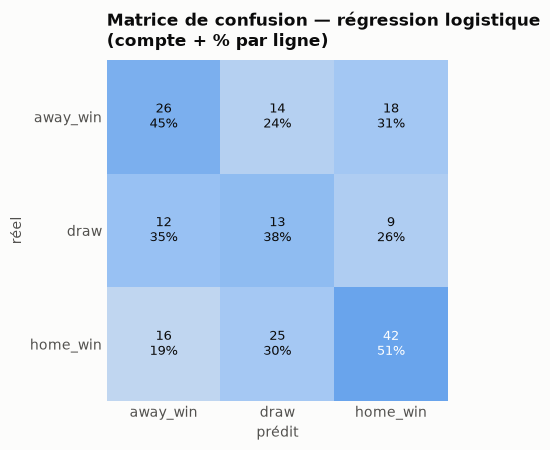

In [26]:
best = logreg  # souvent le meilleur log-loss sur petit dataset ; ajuste si HGB gagne
y_pred = best.predict(X_test)

print(classification_report(y_test, y_pred, labels=CLASSES, digits=3, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm_norm, cmap=BLUES, vmin=0, vmax=1)
ax.set_xticks(range(3), CLASSES); ax.set_yticks(range(3), CLASSES)
ax.set_xlabel("prédit"); ax.set_ylabel("réel")
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]}\n{cm_norm[i,j]:.0%}", ha="center", va="center",
                fontsize=9, color="#ffffff" if cm_norm[i,j] > 0.5 else INK)
ax.set_title("Matrice de confusion — régression logistique\n(compte + % par ligne)", fontweight="bold", pad=10)
fig.tight_layout()
plt.show()

## 5. Ce qui compte pour le modèle

Importance par **permutation** (dégradation du log-loss quand on mélange une feature) — plus honnête que les
coefficients bruts et valable pour les deux modèles.

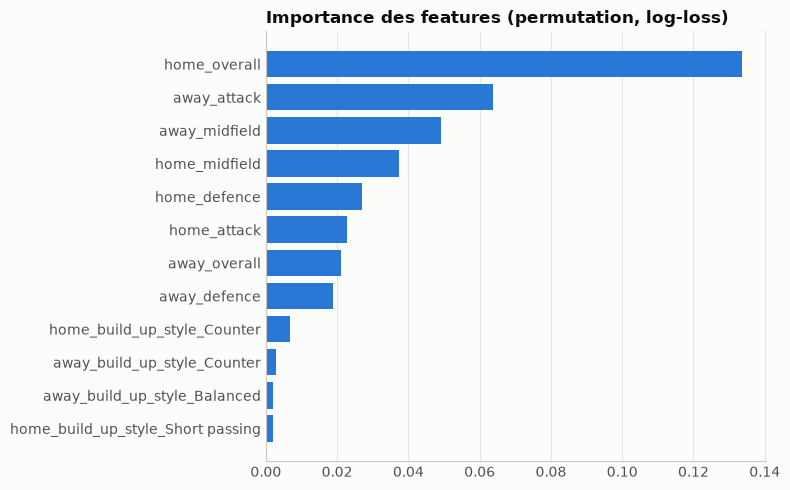

,feature,importance
0,home_overall,0.133622
9,away_attack,0.063737
10,away_midfield,0.049089
2,home_midfield,0.037256
3,home_defence,0.027062
1,home_attack,0.022781
8,away_overall,0.021183
11,away_defence,0.018833
6,home_build_up_style_Counter,0.006895
14,away_build_up_style_Counter,0.002711


In [27]:
imp = permutation_importance(best, X_test, y_test, scoring="neg_log_loss",
                             n_repeats=20, random_state=RANDOM_STATE)
imp_df = (pd.DataFrame({"feature": feature_cols, "importance": imp.importances_mean})
          .sort_values("importance", ascending=False))

top = imp_df.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["importance"].clip(lower=0), color=COLOR_HIGHLIGHT)
ax.set_title("Importance des features (permutation, log-loss)", fontweight="bold")
ax.grid(axis="x"); ax.set_axisbelow(True); ax.tick_params(length=0)
fig.tight_layout()
plt.show()
display(imp_df.head(12))

## 6. Amélioration : features de différence

Pour un résultat, ce qui compte c'est l'**écart** entre les deux équipes, pas les valeurs absolues. On remplace les
paires `home_/away_` par leurs **différences** (`overall_diff = home - away`, etc.) : moins de colonnes, moins de
surapprentissage, souvent aussi bon ou mieux.

In [28]:
num_pairs = ["overall", "defensive_line"]   # att/mid/def retires (redondants avec overall)
diff = pd.DataFrame({f"{p}_diff": df[f"home_{p}"] - df[f"away_{p}"] for p in num_pairs})
# on garde aussi les styles (one-hot déjà présents)
style_cols = [c for c in feature_cols if "build_up_style" in c]
Xd = pd.concat([diff, df[style_cols]], axis=1)

Xd_train, Xd_test = Xd.iloc[:cut], Xd.iloc[cut:]
logreg_diff = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE, class_weight="balanced")
).fit(Xd_train, y_train)

proba = logreg_diff.predict_proba(Xd_test)[:, [list(logreg_diff.classes_).index(c) for c in CLASSES]]
results.append(evaluate("logreg (features de différence)", y_test, logreg_diff.predict(Xd_test), proba))

print("\n=== récapitulatif final ===")
display(pd.DataFrame(results).set_index("model"))

logreg (features de différence) accuracy=0.429  log_loss=1.051

=== récapitulatif final ===


,accuracy,log_loss
model,,
baseline classe majoritaire,0.474,1.040
baseline meilleur overall,0.446,1.040
régression logistique,0.463,1.062
arbre boosté (HGB),0.491,1.069
logreg (features de différence),0.429,1.051


## Conclusion

- Le modèle **bat les baselines** (à confirmer avec les chiffres ci-dessus) — le signal des ratings est réel, mais
  modeste : le 1X2 reste dur, et une bonne partie de l'écart de qualité est déjà résumée par l'`overall`.
- **Le nul est mal prédit** (rappel faible) : c'est intrinsèque, le nul ne se lit pas sur une échelle de force. Deux
  leviers si besoin : `class_weight="balanced"` (remonte le rappel du nul, au prix de l'accuracy/log-loss), ou passer
  à un **modèle de score (Poisson)** d'où le nul émerge naturellement quand λ_dom ≈ λ_ext.
- **Petit dataset** : les scores du holdout sont bruités. Pour les fiabiliser → `TimeSeriesSplit` (validation
  croisée temporelle).
- Les **probabilités** (`predict_proba`) sont la vraie sortie utile : elles alimentent aussi bien un pronostic
  calibré que la couche d'explication LLM qu'on évoquait.

## 7. Interprétation — la bonne métrique en déséquilibre

L'**accuracy est trompeuse** ici : « toujours domicile » fait déjà ~0.47. Pour juger un modèle censé prédire les
**trois** issues, on regarde des métriques **équitables entre classes** :

- **balanced accuracy** — moyenne des rappels des 3 classes (hasard = 0.333). La bonne métrique « générale » ici :
  elle récompense un modèle qui prédit vraiment les 3 issues, pas seulement `home_win`.
- **macro-F1** — F1 moyen des 3 classes à parité ; pénalise l'abandon du nul.
- **Cohen's kappa** — accord au-delà du hasard (≤0 = nul, 0.0-0.2 faible, 0.2-0.4 passable, 0.4+ correct).
- **log-loss** — qualité des **probabilités** (plus bas = mieux) ; c'est ce qui se dégrade avec `class_weight`.

In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score, cohen_kappa_score

def metric_row(name, model, Xte):
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, [list(model.classes_).index(c) for c in CLASSES]]
    return {
        "modèle": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_acc": balanced_accuracy_score(y_test, pred),
        "macro_F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "weighted_F1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "kappa": cohen_kappa_score(y_test, pred),
        "log_loss": log_loss(y_test, proba, labels=CLASSES),
    }

metrics = pd.DataFrame([
    metric_row("régression logistique", logreg, X_test),
    metric_row("arbre boosté (HGB)", hgb, X_test),
]).set_index("modèle").round(3)
print("=== métriques générales (test) ===")
display(metrics)

print("=== détail par classe (régression logistique) ===")
print(classification_report(y_test, logreg.predict(X_test), labels=CLASSES, digits=3, zero_division=0))

# lecture rapide
r = metric_row("logreg", logreg, X_test)
cmv = confusion_matrix(y_test, logreg.predict(X_test), labels=CLASSES)
rappel_nul = cmv[1, 1] / max((y_test == "draw").sum(), 1)
print(f"\nLecture : balanced_acc={r['balanced_acc']:.3f} (hasard 0.333)  |  "
      f"macro_F1={r['macro_F1']:.3f}  |  kappa={r['kappa']:.3f}  |  "
      f"rappel du nul={rappel_nul:.0%}  |  log_loss={r['log_loss']:.3f}")

### Comment trancher

- Objectif **« bien prédire les 3 issues »** → regarde **balanced accuracy / macro-F1 / kappa**. Avec
  `class_weight="balanced"`, le nul est enfin prédit, donc ces trois-là montent.
- Objectif **« probabilités fiables »** (pronostic calibré, couche LLM) → regarde le **log-loss**, et là
  `class_weight` fait plutôt du mal : la repondération éloigne les probas des vraies fréquences.
- **kappa proche de 0** = le modèle ne fait pas beaucoup mieux que le hasard éclairé — cohérent avec le fait que le
  1X2 à partir des seuls ratings d'équipe est intrinsèquement limité (le nul reste le point dur).

En un mot : **balanced accuracy** (ou macro-F1) est ta « métrique générale » honnête ; le log-loss dit si tes
probabilités valent quelque chose. Regarde les deux, pas juste l'accuracy.

## 8. Référence : classifieurs dummy

Pour situer le modèle, on le compare à des classifieurs **sans aucune intelligence** (`DummyClassifier`), sur les
**mêmes métriques** :

- **priors** — prédit toujours la classe majoritaire ; `predict_proba` = fréquences du train (bonne référence de log-loss).
- **aléatoire pondéré** — tire au hasard selon les fréquences des classes.
- **uniforme** — 1/3 pour chaque issue (référence « aucune information » : log-loss = ln 3 ≈ 1.099).

Un modèle utile doit **battre le meilleur dummy** sur `balanced_acc` / `macro_F1` / `kappa`.

In [ ]:
from sklearn.dummy import DummyClassifier

dummies = {
    "dummy — priors":           DummyClassifier(strategy="prior"),
    "dummy — aléatoire pondéré": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "dummy — uniforme":          DummyClassifier(strategy="uniform", random_state=RANDOM_STATE),
}

rows = []
for name, dc in dummies.items():
    dc.fit(X_train, y_train)
    rows.append(metric_row(name, dc, X_test))
rows.append(metric_row("régression logistique", logreg, X_test))
rows.append(metric_row("arbre boosté (HGB)", hgb, X_test))

comparison = pd.DataFrame(rows).set_index("modèle").round(3)
print("=== dummies vs modèles (test) ===")
display(comparison)

ref = comparison.loc[[i for i in comparison.index if i.startswith("dummy")], "balanced_acc"].max()
lr = comparison.loc["régression logistique", "balanced_acc"]
print(f"\nmeilleur dummy balanced_acc = {ref:.3f} (≈ hasard 0.333)")
print(f"logreg balanced_acc         = {lr:.3f}  ->  écart +{lr - ref:.3f}")

**Lecture** : si `balanced_acc` / `macro_F1` du modèle dépassent nettement le meilleur dummy, le modèle apprend un
vrai signal ; si l'écart est petit, il ne fait guère mieux que deviner intelligemment. Le `kappa` dit la même chose
en un chiffre (les dummies sont à ~0 par construction). Le **log-loss** doit lui aussi battre le dummy `priors`
(≈ 1.040) — sinon les probabilités ne valent rien.